In [1]:
import pandas as pd
import sys
import os
import jax
from arviz.labels import MapLabeller

sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_combined_figure
)

/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get data

In [2]:
df = pd.read_csv('data.csv')
# Check
print('Unique graders:', set(df['grader']))
print('Unique models:', set(df['LLM']))
df.head(5)

Unique graders: {'Autograder', 'Human'}
Unique models: {'LLM A', 'LLM B'}


,score,grader,LLM
0,8,Human,LLM A
1,7,Human,LLM A
2,5,Human,LLM A
3,6,Human,LLM A
4,8,Human,LLM A


# Fit model

In [3]:
# Define covariates and outcome
main_effects = ['grader', 'LLM']  # categorical variables
interactions = None
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encode the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

# Fit model and get idata
rng_key = jax.random.PRNGKey(0)
mcmc, idata = fit_model_and_extract_idata(
    rng_key, 
    covariates_dict, 
    y, 
    main_effects, 
    interactions, 
    category_maps
)

sample: 100%|██████████| 2000/2000 [00:04<00:00, 416.56it/s, 31 steps of size 1.69e-01. acc. prob=0.94]


## Fitted parameters

In [4]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
         b_LLM[0]      1.91      0.14      1.90      1.65      2.12    844.31      1.00
      b_grader[0]     -2.18      0.15     -2.18     -2.43     -1.94    697.47      1.00
cutpoint_diffs[0]      0.79      0.19      0.77      0.50      1.13    909.45      1.00
cutpoint_diffs[1]      0.81      0.16      0.80      0.55      1.07    945.57      1.00
cutpoint_diffs[2]      1.31      0.21      1.30      0.97      1.67    872.06      1.00
cutpoint_diffs[3]      0.95      0.18      0.94      0.64      1.20    988.64      1.00
cutpoint_diffs[4]      1.40      0.16      1.40      1.15      1.67   1049.63      1.00
cutpoint_diffs[5]      2.09      0.28      2.09      1.63      2.52    830.07      1.00
cutpoint_diffs[6]      1.32      0.20      1.30      0.95      1.62    817.06      1.00
cutpoint_diffs[7]      1.41      0.32      1.39      0.83      1.85    985.28      1.00
cutpoint_diffs[8]      0.68    

## Check

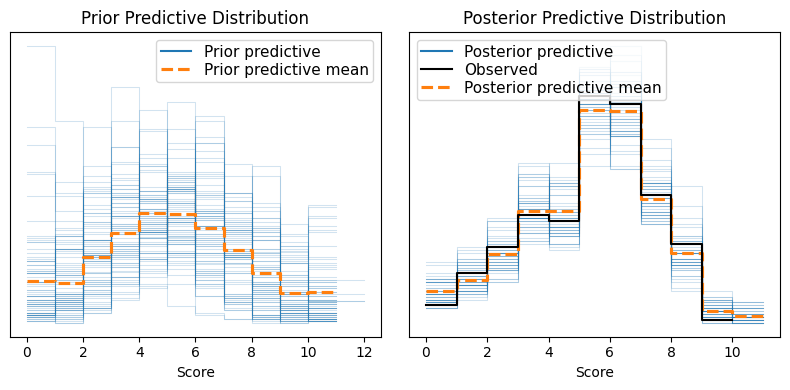

In [5]:
plot_predictive_distributions(idata, fig_path="fig_predictive.png")

# Figure

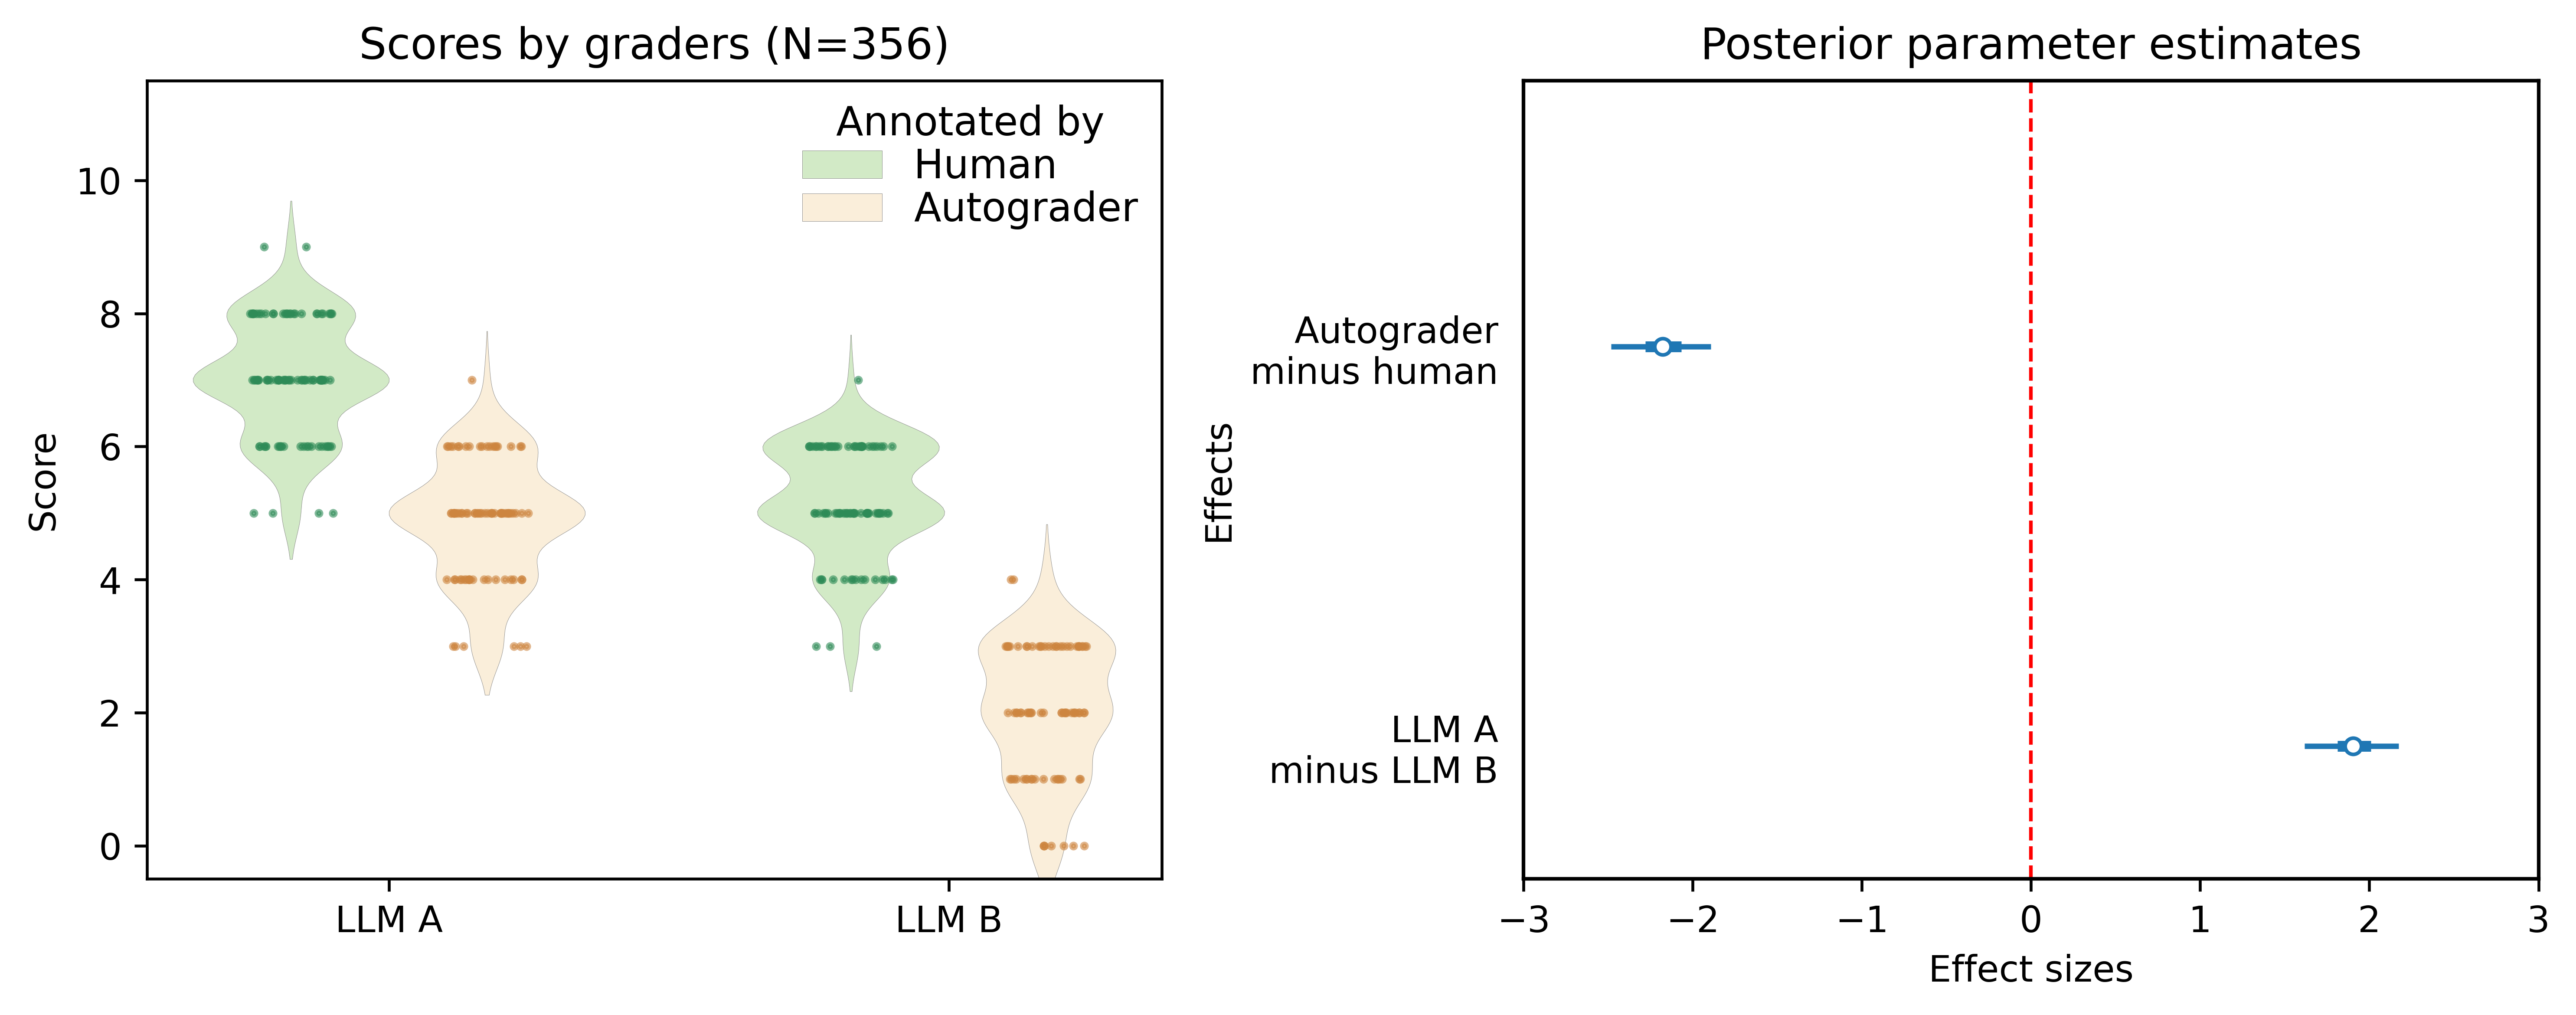

In [6]:
labeller = MapLabeller(
    var_name_map={
        "b_grader": "Autograder\nminus human",
        "b_LLM": "LLM A\nminus LLM B",
    }
)

plot_combined_figure(
    df=df,
    idata=idata,
    var_names=["b_grader", "b_LLM"],
    labeller=MapLabeller(
        var_name_map={
            "b_grader": "Autograder\nminus human",
            "b_LLM": "LLM A\nminus LLM B",
        }
    ),
    color_scheme='1autograder',
    x_var='LLM',                 
    x_label=None,          
    dodge=True,                   
    fig_path="../../figures/figure2.png",
    legend_title='Annotated by',
    xlim=[-3, 3],
    show_predictions=False,
    category_maps=category_maps                  
)
